In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import RandomOverSampler

In [3]:
df = pd.read_csv(r"D:\first_iterations\ishrat-vowel-only\CSVs\vowel_only_features_ordered.csv")

print(df.shape)
df.head()

(2739, 55)


,id,age,gender,smoker,cold_present,cough_present,fever_present,disease,duration,mfcc_1_mean,...,f0_range,jitter,shimmer,hnr,F1_mean,F1_std,F2_mean,F2_std,F3_mean,F3_std
0,AxuYWBN0jFVLINCBqIW5aZmGCdu1,25,male,True,False,False,False,healthy,4.448,-261.06150,...,26.977670,0.063106,0.084838,8.002855,479.023436,81.930207,1175.811095,446.134532,2626.882504,203.981827
1,C5eIsssb9GSkaAgIfsHMHeR6fSh1,28,female,NaN,False,False,False,healthy,4.136,-381.14285,...,28.812624,0.002356,0.009739,31.252150,692.890965,300.751630,1081.489460,438.119060,3196.684644,208.960047
2,YjbEAECMBIaZKyfqOvWy5DDImUb2,26,male,NaN,True,False,False,healthy,4.808,-524.06670,...,48.656258,0.005623,0.100425,15.269618,746.350223,229.979117,2195.730408,512.125140,3296.151442,304.174295
3,aGOvk4ji0cVqIzCs1jHnzlw2UEy2,32,male,NaN,False,False,False,healthy,4.968,-267.69693,...,96.833546,0.006042,0.082920,14.007546,673.461434,265.197041,1318.721615,443.686482,3209.651072,544.084580
4,yWp5tMRFDzbbeEe2csKNd909fqh1,33,male,NaN,False,False,False,healthy,4.552,-362.67044,...,10.109143,0.002880,0.047145,24.349393,378.806702,167.240185,798.847899,338.672028,2521.131434,210.290944


In [4]:
vowel_features = [
    "mfcc_1_mean","mfcc_2_mean","mfcc_3_mean","mfcc_4_mean","mfcc_5_mean",
    "mfcc_6_mean","mfcc_7_mean","mfcc_8_mean","mfcc_9_mean","mfcc_10_mean",
    "mfcc_11_mean","mfcc_12_mean","mfcc_13_mean",

    "mfcc_1_std","mfcc_2_std","mfcc_3_std","mfcc_4_std","mfcc_5_std",
    "mfcc_6_std","mfcc_7_std","mfcc_8_std","mfcc_9_std","mfcc_10_std",
    "mfcc_11_std","mfcc_12_std","mfcc_13_std",

    "f0_mean","f0_std","f0_min","f0_max","f0_range",

    "jitter","shimmer","hnr",

    "F1_mean","F1_std","F2_mean","F2_std","F3_mean","F3_std",

    "rms_mean","rms_std","zcr_mean","zcr_std",

    "spectral_centroid_mean","spectral_flatness_mean",

    "duration"
]

In [5]:
TARGET_COL = "disease"

df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

X = df[vowel_features]
y = df[TARGET_COL]

print("X shape:", X.shape)
print("Class distribution:")
print(y.value_counts())

X shape: (2739, 47)
Class distribution:
disease
healthy    1682
covid       541
asthma      352
copd        164
Name: count, dtype: int64


In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['asthma' 'copd' 'covid' 'healthy']


In [7]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.15,
    stratify=y_encoded,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.1765,
    stratify=y_trainval,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1917, 47)
Validation: (411, 47)
Test: (411, 47)


In [8]:
train_df = X_train.copy()
train_df["disease_encoded"] = y_train
train_df["disease"] = label_encoder.inverse_transform(y_train)

val_df = X_val.copy()
val_df["disease_encoded"] = y_val
val_df["disease"] = label_encoder.inverse_transform(y_val)

test_df = X_test.copy()
test_df["disease_encoded"] = y_test
test_df["disease"] = label_encoder.inverse_transform(y_test)

train_df.to_csv(r"D:\first_iterations\ishrat-vowel-only\CSVs\vowel_train.csv", index=False)
val_df.to_csv(r"D:\first_iterations\ishrat-vowel-only\CSVs\vowel_val.csv", index=False)
test_df.to_csv(r"D:\first_iterations\ishrat-vowel-only\CSVs\vowel_test.csv", index=False)

In [9]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [11]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
import numpy as np

print("Original train distribution:")
print(Counter(y_train))

for i, cls in enumerate(label_encoder.classes_):
    print(i, "=", cls)

# Edit these numbers after seeing your class distribution above
target_counts_by_label = {
    "healthy": 1682,
    "covid": 850,
    "asthma": 650,
    "copd": 650
}

Original train distribution:
Counter({np.int64(3): 1178, np.int64(2): 379, np.int64(0): 246, np.int64(1): 114})
0 = asthma
1 = copd
2 = covid
3 = healthy


In [12]:
target_counts = {}

current_counts = Counter(y_train)

for label, target_count in target_counts_by_label.items():
    encoded_label = label_encoder.transform([label])[0]
    
    # only oversample if target is greater than current count
    if target_count > current_counts[encoded_label]:
        target_counts[encoded_label] = target_count

print("Current counts:", current_counts)
print("ROS target counts:", target_counts)

Current counts: Counter({np.int64(3): 1178, np.int64(2): 379, np.int64(0): 246, np.int64(1): 114})
ROS target counts: {np.int64(3): 1682, np.int64(2): 850, np.int64(0): 650, np.int64(1): 650}


In [13]:
ros = RandomOverSampler(
    sampling_strategy=target_counts,
    random_state=42
)

X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

print("After ROS:")
print(Counter(y_train_ros))

After ROS:
Counter({np.int64(3): 1682, np.int64(2): 850, np.int64(1): 650, np.int64(0): 650})


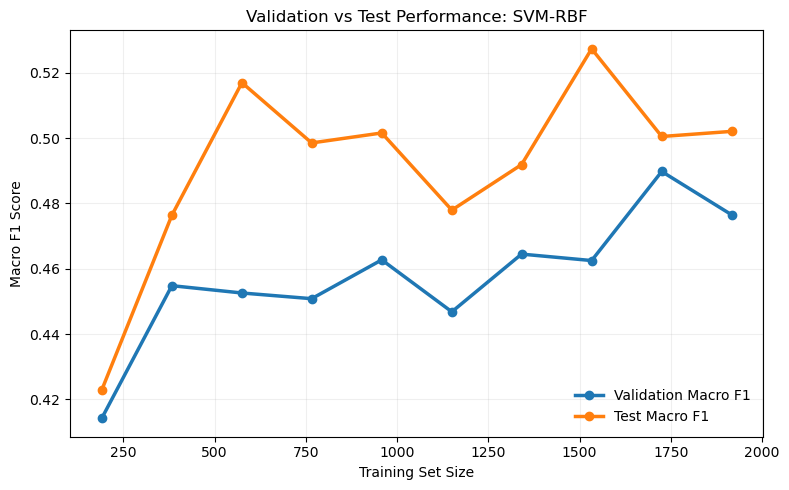

In [28]:
from sklearn.metrics import f1_score
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Fractions of training data to use
fractions = np.linspace(0.1, 1.0, 10)

val_scores = []
test_scores = []
sizes = []

for frac in fractions:
    
    # Subsample training set
    n_samples = int(len(X_train) * frac)
    sizes.append(n_samples)

    X_sub = X_train[:n_samples]
    y_sub = y_train[:n_samples]

    # Fit model
    svm_model.fit(X_sub, y_sub)

    # Validation prediction
    y_val_pred = svm_model.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='macro')

    # Test prediction
    y_test_pred = svm_model.predict(X_test)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')

    val_scores.append(val_f1)
    test_scores.append(test_f1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(sizes, val_scores, marker='o', linewidth=2.5, label='Validation Macro F1')
plt.plot(sizes, test_scores, marker='o', linewidth=2.5, label='Test Macro F1')

plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.title("Validation vs Test Performance: SVM-RBF")

plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=42
    ),

    "SVM RBF": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    )
}

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for name, model in models.items():
    model.fit(X_train_ros, y_train_ros)

    y_val_pred = model.predict(X_val_scaled)

    print("\n" + "="*70)
    print(name)
    print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

    print(classification_report(
        y_val,
        y_val_pred,
        target_names=label_encoder.classes_
    ))


Logistic Regression
Validation Accuracy: 0.4793187347931874
              precision    recall  f1-score   support

      asthma       0.31      0.42      0.35        53
        copd       0.28      0.56      0.37        25
       covid       0.30      0.46      0.36        81
     healthy       0.75      0.49      0.59       252

    accuracy                           0.48       411
   macro avg       0.41      0.48      0.42       411
weighted avg       0.57      0.48      0.50       411


Random Forest
Validation Accuracy: 0.6277372262773723
              precision    recall  f1-score   support

      asthma       0.50      0.25      0.33        53
        copd       0.25      0.16      0.20        25
       covid       0.53      0.11      0.18        81
     healthy       0.66      0.92      0.77       252

    accuracy                           0.63       411
   macro avg       0.48      0.36      0.37       411
weighted avg       0.59      0.63      0.56       411


SVM RBF
Valid

Random Forest has higher accuracy (62.7 > 58.6), BUT I picked SVM RBF because for disease classification our minority classes recall, f1 etc. matters more than just plain accuracy (especially because we also have imbalanced classes)

In [16]:
for name, model in models.items():
    y_val_pred = model.predict(X_val_scaled)

    cm = confusion_matrix(y_val, y_val_pred)

    cm_df = pd.DataFrame(
        cm,
        index=label_encoder.classes_,
        columns=label_encoder.classes_
    )

    print("\n" + "="*70)
    print(name)
    display(cm_df)


Logistic Regression


,asthma,copd,covid,healthy
asthma,22,13,5,13
copd,10,14,0,1
covid,13,3,37,28
healthy,26,20,82,124



Random Forest


,asthma,copd,covid,healthy
asthma,13,4,1,35
copd,7,4,0,14
covid,0,1,9,71
healthy,6,7,7,232



SVM RBF


,asthma,copd,covid,healthy
asthma,23,11,4,15
copd,11,9,1,4
covid,5,2,39,35
healthy,19,10,53,170


In [17]:
#Trying XGBoost

from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train_ros, y_train_ros)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [18]:
#Validation set for XGBoost
y_val_pred_xgb = xgb_model.predict(X_val_scaled)

print("XGBoost Validation Accuracy:", accuracy_score(y_val, y_val_pred_xgb))

print(classification_report(
    y_val,
    y_val_pred_xgb,
    target_names=label_encoder.classes_
))

#Validation confusion matrix
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)

cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_xgb_df

XGBoost Validation Accuracy: 0.6326034063260341
              precision    recall  f1-score   support

      asthma       0.46      0.36      0.40        53
        copd       0.23      0.12      0.16        25
       covid       0.44      0.25      0.32        81
     healthy       0.70      0.87      0.77       252

    accuracy                           0.63       411
   macro avg       0.46      0.40      0.41       411
weighted avg       0.59      0.63      0.60       411



,asthma,copd,covid,healthy
asthma,19,5,4,25
copd,13,3,0,9
covid,0,1,20,60
healthy,9,4,21,218


In [19]:
#Test set for XGBoost

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Predict on test set
y_test_pred_xgb = xgb_model.predict(X_test_scaled)

# Accuracy
print("XGBoost Test Accuracy:", accuracy_score(y_test, y_test_pred_xgb))

# Classification report
print(classification_report(
    y_test,
    y_test_pred_xgb,
    target_names=label_encoder.classes_
))

#Confusion matrix on test set
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

cm_xgb_df = pd.DataFrame(
    cm_xgb,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_xgb_df

XGBoost Test Accuracy: 0.6861313868613139
              precision    recall  f1-score   support

      asthma       0.44      0.23      0.30        53
        copd       0.47      0.36      0.41        25
       covid       0.67      0.32      0.43        81
     healthy       0.72      0.93      0.81       252

    accuracy                           0.69       411
   macro avg       0.58      0.46      0.49       411
weighted avg       0.66      0.69      0.65       411



,asthma,copd,covid,healthy
asthma,12,9,2,30
copd,8,9,0,8
covid,2,0,26,53
healthy,5,1,11,235


In [20]:
#Picked SVM as best model

best_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    random_state=42
)

best_model.fit(X_train_ros, y_train_ros)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [21]:
#SVM (Tuned)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.5, 1, 2],
    "gamma": ["scale", 0.05, 0.01]
}

grid = GridSearchCV(
    SVC(kernel="rbf", class_weight="balanced"),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_ros, y_train_ros)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)

Best params: {'C': 2, 'gamma': 0.05}


In [22]:
#Validation set for SVM (Tuned)

y_val_pred = best_model.predict(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))

print(classification_report(
    y_val,
    y_val_pred,
    target_names=label_encoder.classes_
))

from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_val, y_val_pred)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df

Validation Accuracy: 0.610705596107056
              precision    recall  f1-score   support

      asthma       0.45      0.38      0.41        53
        copd       0.25      0.16      0.20        25
       covid       0.42      0.30      0.35        81
     healthy       0.69      0.81      0.74       252

    accuracy                           0.61       411
   macro avg       0.45      0.41      0.42       411
weighted avg       0.58      0.61      0.59       411



,asthma,copd,covid,healthy
asthma,20,3,2,28
copd,12,4,0,9
covid,2,1,24,54
healthy,10,8,31,203


In [23]:
#Test set for SVM (Tuned)
y_test_pred = best_model.predict(X_test_scaled)

print("SVM Test Accuracy:", accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, y_test_pred)

cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

cm_df

SVM Test Accuracy: 0.6618004866180048
              precision    recall  f1-score   support

      asthma       0.42      0.25      0.31        53
        copd       0.29      0.20      0.24        25
       covid       0.58      0.41      0.48        81
     healthy       0.72      0.88      0.79       252

    accuracy                           0.66       411
   macro avg       0.50      0.43      0.45       411
weighted avg       0.63      0.66      0.63       411



,asthma,copd,covid,healthy
asthma,13,5,3,32
copd,9,5,1,10
covid,4,1,33,43
healthy,5,6,20,221


These findings indicate that while vowel features provide useful information about overall respiratory health (differentiating healthy from non-healthy), they are insufficient for fine-grained disease classification. This motivates the integration of vowel features with cough-based features to improve disease-specific predictive performance.

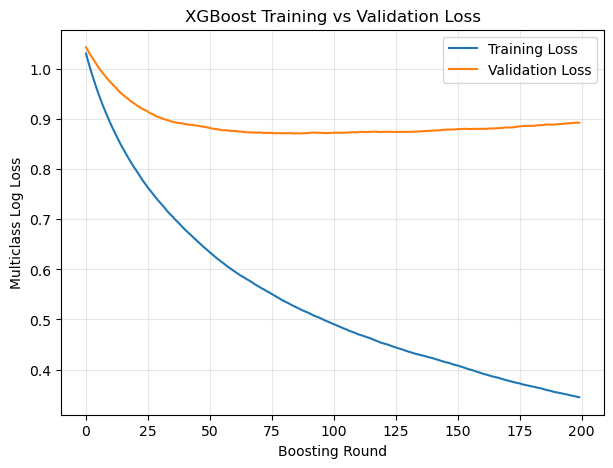

XGBoost Test Accuracy: 0.6715328467153284
              precision    recall  f1-score   support

           0       0.52      0.30      0.38        53
           1       0.50      0.24      0.32        25
           2       0.61      0.21      0.31        81
           3       0.70      0.94      0.80       252

    accuracy                           0.67       411
   macro avg       0.58      0.42      0.45       411
weighted avg       0.64      0.67      0.62       411



In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

results = xgb_model.evals_result()

plt.figure(figsize=(7, 5))
plt.plot(results["validation_0"]["mlogloss"], label="Training Loss")
plt.plot(results["validation_1"]["mlogloss"], label="Validation Loss")
plt.xlabel("Boosting Round")
plt.ylabel("Multiclass Log Loss")
plt.title("XGBoost Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

y_pred = xgb_model.predict(X_test)

print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    C=1,
    gamma="scale",
    random_state=42
)

train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    X_train,
    y_train,
    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training Macro F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Macro F1")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.title("SVM-RBF Learning Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ValueError: 
All the 30 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\svm\_base.py", line 197, in fit
    X, y = validate_data(
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py", line 2971, in validate_data
    X, y = check_X_y(X, y, **check_params)
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py", line 1368, in check_X_y
    X = check_array(
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py", line 1105, in check_array
    _assert_all_finite(
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py", line 120, in _assert_all_finite
    _assert_all_finite_element_wise(
  File "c:\Users\ishra\anaconda3\envs\ml\lib\site-packages\sklearn\utils\validation.py", line 169, in _assert_all_finite_element_wise
    raise ValueError(msg_err)
ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values
